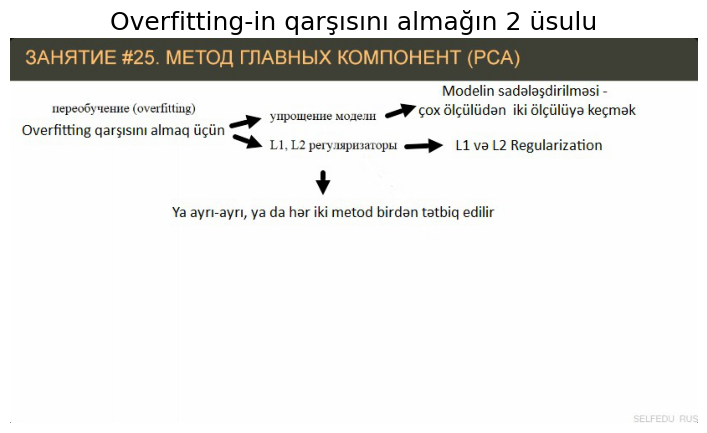

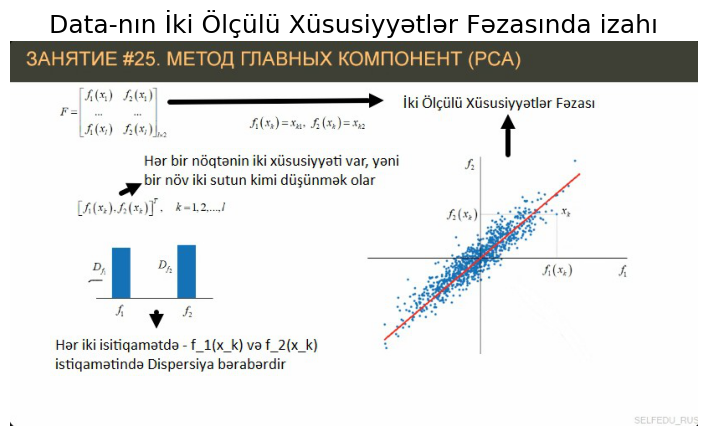

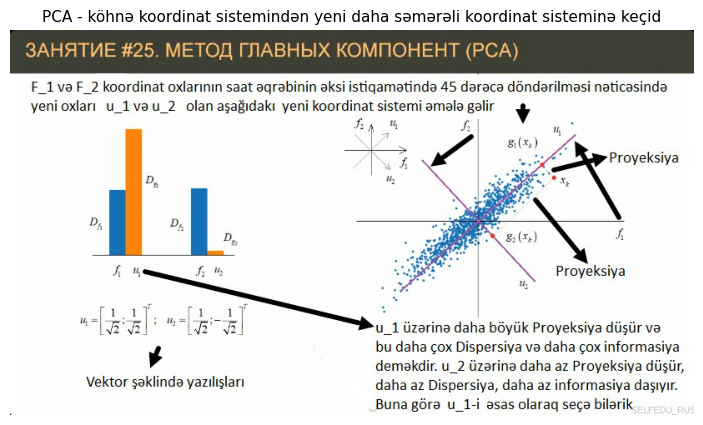

In [9]:
from PIL import Image

# Fayl yolunun əsas hissəsi
base_path = r'C:\Users\dell\Desktop\Selfedu\Pictures\ML_25_'

# Şəkilləri saxlayacağımız siyahı
image_list = []

# 1-dən 5-ə qədər olan şəkilləri dövr ilə açırıq
for i in range(1, 4):  # 1-dən 5-ə qədər
    full_path = f'{base_path}{i}.jpg'  # Fayl yolunu dinamik olaraq yaradırıq
    img = Image.open(full_path)
    image_list.append(img)  # Şəkili siyahıya əlavə edirik

# Nəticə: images siyahısında bütün yüklənmiş şəkillər olacaq

import matplotlib.pyplot as plt

# Şəkilləri göstərin
for i, image in enumerate(image_list):
    if i == 100:
        plt.figure(figsize=(8.8, 4))          
    else:     
        plt.figure(figsize=(25, 5))  # Şəkilin ölçüsü    
        
    if i < 1:
        plt.title("""Overfitting-in qarşısını almağın 2 üsulu""", size='18')
    elif i < 2:
        plt.title("""Data-nın İki Ölçülü Xüsusiyyətlər Fəzasında izahı""", size='18')
    elif i < 3:
        plt.title("""PCA - köhnə koordinat sistemindən yeni daha səmərəli koordinat sisteminə keçid""", size='11')         
    
    plt.imshow(image)
    plt.axis('off')  # Oxları gizlətmək üçün
    plt.show()

### PCA-nın İki Ölçülü Xüsusiyyətlər Fəzasında izahı

> **Şəkil Maşın Öyrənməsində ölçülərin azaldılması (dimensionality reduction) üçün ən çox istifadə olunan alqoritmlərdən biri olan PCA (Principal Component Analysis - Baş Komponentlər Analizi) mövzusuna aiddir.**

- **Gəlin şəkli hissə-hissə, sadə dildə izah edək:**

<br>

#### **1. PCA-nın Əsas Məqsədi**
> **PCA-nın ana məqsədi datadakı informasiyanı (variasiyanı) maksimum dərəcədə qoruyub saxlamaqla xüsusiyyətlərin (f-lərin) sayını azaltmaqdır. Məsələn, şəkildə iki xüsusiyyət ($f_1$ və $f_2$) var, biz onları daha az sayda xüsusiyyətlə ifadə etmək istəyirik.**

<br>

#### **2. Şəkildəki Riyazi İfadələr**
* **Matris ($F$):** **Sol yuxarıda gördüyünüz matris bizim giriş datamızdır. Hər bir sətir bir obyekti, sütunlar isə xüsusiyyətləri göstərir.**
* **$f_1(x_k)$ və $f_2(x_k)$:** **Bunlar hər hansı bir $x_k$ obyektinin koordinatlarıdır.**
* **$D_{f1}$ və $D_{f2}$ (Dispersiya):** **Sol tərəfdəki sütun qrafikləri xüsusiyyətlərin **dispersiyasını** (məlumatın nə dərəcədə yayıldığını) göstərir. PCA-da yüksək dispersiya = daha çox informasiya deməkdir.**

<br>

#### **3. Qrafikin İzahı (Əsas Məqam)**
- **Sağ tərəfdəki qrafikdə göy nöqtələr datanı, qırmızı xətt isə PCA-nın tapdığı birinci baş komponenti (PC1) göstərir:**
    * **İnformasiya itkisinin qarşısını almaq:** **Nöqtələr qırmızı xətt boyunca daha çox yayılıb. Bu o deməkdir ki, datadakı əsas variasiya məhz bu istiqamətdədir.**
    * **Proyeksiya:** **PCA hər bir göy nöqtəni o qırmızı xəttin üzərinə proyeksiya edir. Beləliklə, biz iki ox ($f_1, f_2$) yerinə, datanı tək bir yeni ox (qırmızı xətt) üzərində ifadə edə bilirik.**
    * **Korrelyasiya:** **Diqqət etsəniz, $f_1$ artdıqca $f_2$ də artır (güclü xətti əlaqə). PCA bu asılılığı istifadə edərək artıq xüsusiyyətləri silir və onları yeni bir oxda birləşdirir.**

<br>

#### **4. Nəticə etibarilə nə baş verir?**
- **1.  Ölçü azalır: Biz 2D qrafikdən 1D qrafikə (yalnız qırmızı xəttin üzərindəki mövqeyə) keçid edirik.**
- **2.  Yaddaşa qənaət: Data daha kiçik ölçüdə saxlanılır.**
- **3.  Vizualizasiya: Çoxölçülü datanı (məsələn, 100 xüsusiyyəti) 2 və ya 3 ölçüyə salıb qrafikdə görmək mümkün olur.**

**Xülasə:** 
> **Şəkildə PCA-nın datadakı ən yüksək variasiya istiqamətini (qırmızı xətti) necə tapdığı və məlumatın həmin xətt üzərində necə cəmləşdiyi göstərilmişdir.**

### $D_{f1}$ və $D_{f2}$ niyə bərabərdir?

> **Şəkildəki sol tərəfdəki sütun qrafiklərinə ($D_{f1}$ və $D_{f2}$) diqqət yetirsək, onların hündürlüklərinin demək olar ki, eyni olduğunu görürük. Bunun bir neçə fundamental səbəbi ola bilər:**

<br>

#### **1. Data Standartlaşdırılıb (Scaling)**
- **PCA alqoritmini tətbiq etməzdən əvvəl atılan ən vacib addım datanı standartlaşdırmaqdır (Standardization):** 
    * **Əgər biz hər iki xüsusiyyəti ($f_1$ və $f_2$) orta qiyməti 0, dispersiyası isə 1 olacaq şəkildə miqyaslandırsaq, onların dispersiyaları bərabərləşir ($D_{f1} = D_{f2} = 1$).** 
    * **Niyə edilir?** **Çünki əgər $f_1$ gəlir (minlərlə), $f_2$ isə yaş (onlarla) olsa, PCA böyük rəqəmlərə daha çox əhəmiyyət verəcək və nəticə səhv olacaq. Dispersiyaların bərabər olması modelin hər iki xüsusiyyətə eyni dərəcədə "ədalətli" yanaşdığını göstərir.**

<br>

#### **2. Xüsusiyyətlərin Paylanma Oxşarlığı**
- **Qrafikdəki göy nöqtələrə baxsaq, onların $f_1$ oxu boyunca yayıldığı məsafə ilə $f_2$ oxu boyunca yayıldığı məsafə vizual olaraq bir-birinə çox yaxındır.**
* **Nöqtələr 45 dərəcəlik bir xətt boyunca simmetrik paylanıb.** 
* **Bu o deməkdir ki, datanın "səpələnmə dərəcəsi" hər iki istiqamətdə eynidir.**

<br>

#### **3. PCA-nın tapdığı "Yeni" Oxun Gücü**
- **Şəkildəki qırmızı xətt (birinci baş komponent) məhz o dispersiyaların "cəmini" öz üzərinə götürmək üçün oradadır.**
- $f_1$ və $f_2$ **ayrılıqda eyni miqdarda informasiya (eyni dispersiya) daşısa da, onlar bir-biri ilə korrelyasiyadadırlar.**
- **PCA bu iki bərabər dispersiyanı birləşdirib, daha böyük bir dispersiyaya malik olan tək bir ox yaradır.**

<br>

#### **Xülasə**
> **Şəkildə dispersiyaların bərabər göstərilməsi çox gümman ki, StandardScaler (və ya bənzər bir metod) tətbiq edildikdən sonra datanın hər iki ölçüdə eyni çəkiyə malik olduğunu vurğulamaq üçündür. Əgər biri digərindən çox böyük olsaydı, PCA avtomatik olaraq həmin oxu "əsas" seçərdi və digər vacib məlumatları itirə bilərdik.**

#### PCA alqoritminin – yəni datanın köhnə koordinat sistemindən yeni, daha səmərəli koordinat sisteminə keçidi

> **Şəkil PCA (Baş Komponentlər Analizi) alqoritminin riyazi və həndəsi olaraq ən pik nöqtəsini – yəni datanın köhnə koordinat sistemindən yeni, daha səmərəli koordinat sisteminə keçidini izah edir.**

- **Gəlin hər bir detalı addım-addım təhlil edək:**

<br>

#### **1. Ümumi Prinsip: Niyə belə etdik?**
- **Bizim ilkin datamız $f_1$ və $f_2$ oxları üzərində paylanıb. Diqqət etsəniz, bu iki dəyişən arasında güclü korrelyasiya var (yəni $f_1$ artdıqca $f_2$ də artır). Bu o deməkdir ki, hər iki ox əslində eyni informasiyanın böyük bir hissəsini təkrarlayır.**
- **Məqsədimiz:** **Datanı elə yeni oxlara (baş komponentlərə) köçürməkdir ki:**
    - **1.  Birinci ox ($u_1$) datadakı maksimum dispersiyanı (informasiyanı) özündə cəmləsin.**
    - **2.  İkinci ox ($u_2$) isə birinciyə perpendikulyar olsun və qalan minimal məlumatı daşısın.**

- $\large{⚠️}$ **Diqqət**
> **BU $u_1$ və $u_2$ oxları $f_1$ və $f_2$ oxlarının xəyali olaraq saat ərəbinin əksi istqamətində 45 dərəcə döndərilməsi nəticəsində yaranır**

<br>

#### **2. $u_1$ və $u_2$ nədir? (Vektorlar)**
- **Şəkildə sol aşağıda gördüyünüz $u_1$ və $u_2$ Vahid Vektorlardır (Unit Vectors):**
    $$
    u_1 = \left[ \frac{1}{\sqrt{2}}, \frac{1}{\sqrt{2}} \right]^T, \quad u_2 = \left[ \frac{1}{\sqrt{2}}, -\frac{1}{\sqrt{2}} \right]^T
    $$
    
    - **$u_1$:** **Bu vektor 45 dərəcəlik bucaq altında yönəlib. Qrafikdə bənövşəyi rəngli əsas xətt məhz bu istiqamətdədir. Data ən çox bu istiqamətdə uzanır.**
    - **$u_2$:** **Bu vektor $u_1$-ə perpendikulyardır. O, datanın ən az yayıldığı (eni) istiqaməti göstərir.**
    - **Niyə bu rəqəmlər?** $\sqrt{1/2}^2 + \sqrt{1/2}^2 = 1$ edir. **Bu, vektorun uzunluğunun 1 olduğunu və sadəcə istiqamət bildirdiyini göstərir.**

<br>

#### **3. Dispersiyalar ($D$) niyə müxtəlif oldu?**
- **Sol tərəfdəki bar-qrafikə baxın:**
    * **Əvvəl:** $D_{f1}$ və $D_{f2}$ **demək olar ki, bərabər idi (göy sütunlar). Bu o deməkdir ki, köhnə oxların heç biri datanı təkbaşına tam ifadə edə bilmirdi.**
    * **Sonra ($D_{u1}$):** **Narıncı sütun çox hündürdür! Çünki biz oxu dəyişib datanın ən çox uzandığı istiqamətə ($u_1$) qoyduq. İndi bütün informasiya (dispersiya) bu oxda cəmləndi.**
    * **Sonra ($D_{u2}$):** **Çox kiçik bir narıncı sütun qaldı. Çünki o istiqamətdə demək olar ki, dəyişiklik (yayılma) yoxdur.**

<br>

#### **4. Qrafik neçə o hala gəldi? (Proyeksiya)**
- **Qrafikdəki $x_k$ nöqtəsinə və ondan oxlara çəkilən qırıq-qırıq xətlərə baxın:**
    * **$g_1(x_k)$:** **Bu, nöqtənin yeni $u_1$ oxu üzərindəki proyeksiyasıdır. Artıq obyektin "əsas kimliyi" bu rəqəmdir.**
    * **$g_2(x_k)$:** **Bu rəqəm isə nöqtənin $u_1$ xəttindən nə qədər kənara çıxdığını (səhvini və ya incə detalını) göstərir.**

**Proses belə oldu:**
- **1.  Datanın mərkəzi tapıldı (0,0 nöqtəsi).**
- **2.  Data buludunun içindən ən uzun məsafəni keçən düz xətt ($u_1$) çəkildi.**
- **3.  Bütün nöqtələr bu yeni xəttin üzərinə "yıxıldı" (proyeksiya edildi).**
- **4.  Köhnə $f_1, f_2$ koordinat sistemi ləğv edildi, yeni $u_1, u_2$ sistemi yaradıldı.**

<br>

#### **Yekun Nəticə:**
- **Biz bu hərəkətlə nə qazandıq?**
> **Əgər biz $u_2$ oxunu tamamilə silsək (çünki $D_{u2}$ çox kiçikdir), datanın bəlkə də 95%-ni qoruyub saxlayaraq onu iki ölçüdən bir ölçüyə (2D-dən 1D-yə) endirmiş oluruq. Bu, həm hesablama sürətini artırır, həm də datadakı "küyü" (noise) təmizləyir.**

### $u_1$ və $u_2$ vektorlarının necə doğulduğunun riyazi izahı

> **Bu işin "mətbəxi" məhz bura – Xüsusi Vektorlar (Eigenvectors) və Xüsusi Qiymətlər (Eigenvalues) mövzusuna söykənir. Gəlin, o $u_1$ və $u_2$ vektorlarının necə doğulduğunu riyazi olaraq addım-addım izah edim.**

<br>

#### **1. Kovariasiya Matrisi ($\Sigma$)**
- **Hər şey datanın daxili əlaqələrini göstərən Kovariasiya Matrisinin hesablanması ilə başlayır. Əgər bizim datamız $f_1$ və $f_2$ oxlarından ibarətdirsə, matris belə görünür:**

    $$
    \Sigma = \begin{pmatrix} \text{Var}(f_1) & \text{Cov}(f_1, f_2) \\ \text{Cov}(f_2, f_1) & \text{Var}(f_2) \end{pmatrix}
    $$

    * **Var:** **Hər bir xüsusiyyətin öz daxilindəki yayılması.**
    * **Cov:** **İki xüsusiyyətin bir-biri ilə nə dərəcədə əlaqəli (korrelyasiyada) olduğu.**

<br>

#### **2. Xüsusi Qiymət Tənliyi (Characteristic Equation)**
- **Biz elə bir $\lambda$ (lambda) və $u$ vektoru tapmalıyıq ki, bu tənliyi ödəsin:**
    $$
    \Sigma u = \lambda u
    $$

    - **Bu tənlik bizə deyir ki: "Mən bu $u$ vektorunu kovariasiya matrisi ilə vurduqda, o öz istiqamətini dəyişməsin, sadəcə $\lambda$ qədər uzansın və ya qısalsın."**

- **Bunu tapmaq üçün determinantdan istifadə edirik:**
    $$\det(\Sigma - \lambda I) = 0$$

    - **Buradan tapılan $\lambda_1$ və $\lambda_2$ sizin şəkildə gördüyünüz o narıncı sütunların ($D_{u1}$ və $D_{u2}$) hündürlüyüdür. Yəni hər bir oxun nə qədər informasiya (dispersiya) daşıdığı rəqəmsal olaraq ortaya çıxır.**

<br>

#### **3. Xüsusi Vektorların ($u_1, u_2$) tapılması**
- **Tapdığımız hər bir $\lambda$ üçün tənliyi yenidən həll edib $u$ vektorlarını tapırıq.**

* **$\lambda_{max}$ (ən böyük qiymət):** **Bu qiymətə uyğun gələn $u_1$ vektoru Birinci Baş Komponentdir. O, datanın ən çox uzandığı (ən böyük dispersiyaya malik) istiqaməti göstərir.**
* **Digər $\lambda$:** **Ona uyğun gələn $u_2$ isə həmişə $u_1$-ə perpendikulyar olur və qalan dispersiyanı göstərir.**

<br>

#### **4. Şəkildəki $1/\sqrt{2}$ rəqəmi haradan gəldi?**
- **Sizin şəkildəki $u_1 = [1/\sqrt{2}, 1/\sqrt{2}]$ nümunəsi datanın tam 45 dərəcəlik bucaq altında paylandığı (yəni $f_1$ və $f_2$ arasındakı korrelyasiyanın tam olduğu) hala aiddir.** 
- **Vektorun uzunluğunu 1-ə bərabər etmək üçün (normalizasiya) biz hər bir komponenti vektorun normasına bölürük:**
    $$\|u\| = \sqrt{(1)^2 + (1)^2} = \sqrt{2}$$
    - **Ona görə də vahid vektor $1/\sqrt{2}$ olur.**

<br>

#### **Ümumi Məntiqin Xülasəsi**
- **1.  Kovariasiya Matrisi datanın daxili "xəritəsini" çıxarır.**
- **2.  Xüsusi Qiymətlər ($\lambda$) bu xəritədə hansı istiqamətin daha "zəngin" (çox məlumatlı) olduğunu deyir.**
- **3.  Xüsusi Vektorlar ($u$) isə həmin istiqamətlərin koordinatlarını (oxlarını) bizə verir.**

> **Bu proses bitdikdən sonra biz köhnə $f_1$ və $f_2$ oxlarını "zibil qutusuna" atırıq və datanı yeni, daha güclü $u_1$ oxu üzərində ifadə edirik.**